In [1]:
import torch
from torch import Tensor, nn
from typing import Dict, Optional
from math import ceil
import numpy as np
from torch.autograd import Function
import os
from torch.autograd.function import Function
from functools import partial
import math
import triton
from copy import deepcopy
import triton.language as tl
from triton.tools.tensor_descriptor import TensorDescriptor

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(DEVICE)


cuda


In [2]:
os.environ["TRITON_PRINT_AUTOTUNING"] = "1"

In [3]:
ACT_INTERFACE = {
    "gelu": nn.GELU(),
    "leaky_relu": nn.LeakyReLU(),
    "relu": nn.ReLU(),
    "sigmoid": nn.Sigmoid(),
    "silu": nn.SiLU(),
    "swish": nn.SiLU(),
    "tanh": nn.Tanh(),
    "no_act": nn.Identity(),
}


def eager_forward(
    x: Tensor,
    WT_up: Tensor,
    b_up: Optional[Tensor],
    WT_gp: Tensor,
    b_gp: Optional[Tensor],
    act_fn: str,
    dropout_p: float,
) -> Tensor:
    
    # up = x @ WT_up.T
    # if b_up is not None:
    #     up += b_up
    up = nn.functional.linear(x, WT_up.T, b_up)
        
    # gated = x @ WT_gp.T
    # if b_gp is not None:
    #     gated += b_gp
    gated = nn.functional.linear(x, WT_gp.T, b_gp)
        
    gated = ACT_INTERFACE[act_fn]((gated))
    out = gated * up
    # x = nn.functional.dropout(x, dropout_p, training)
    return out


class NaiveGatedMLP(nn.Module):
    def __init__(
        self,
        hidden_size: int = 256,
        intermediate_size: int = 512,
        bias: bool = True,
        hidden_act: str = "silu",
        dropout_p: float = 0.0,
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.intermediate_size = intermediate_size
        self.gate_proj = nn.Linear(self.hidden_size, self.intermediate_size, bias=bias)
        self.up_proj = nn.Linear(self.hidden_size, self.intermediate_size, bias=bias)
        self.down_proj = nn.Linear(self.intermediate_size, self.hidden_size, bias=bias)
        self.act = ACT_INTERFACE[hidden_act]
        self.act_fn = hidden_act
        self.dropout = nn.Dropout(dropout_p)
    
    def forward(self, x):
        # We are fusing only the first computation that provides the hidden states, 
        # so for a fair comparison for now we comment the down_proj step
        hidden_states = self.dropout(self.act(self.gate_proj(x)) * self.up_proj(x))
        # down_proj = self.down_proj(hidden_states)
        return hidden_states


In [4]:

def pad_tensor_16_byte_aligned(t: Tensor, axis: int) -> Tensor:
    assert t.ndim == 2, f"expected tensor to have exactly 2 dimensions, got {t.ndims}"
    old_dim = t.shape[axis]
    pad_amount = 16 - old_dim % 16
    pad = (pad_amount, 0) if axis == 0 else (0, pad_amount)
    return torch.nn.functional.pad(t, pad)

def is_hopper():
    return torch.cuda.get_device_capability()[0] == 9

@triton.jit()
def _compute_sigma(x):
    return 1 / (1 + tl.exp(-x))

@triton.jit()
def _silu_fwd(x):
    return x * _compute_sigma(x)

@triton.jit()
def _act_fwd(x, act_name: tl.constexpr):
    if act_name == "no_act":
        return x
    elif act_name == "silu":
        return _silu_fwd(x)
    else:
        raise NotImplementedError()

@triton.jit()
def map_pid_m_n(pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M, optimize_L2):
    if optimize_L2:
        pid_m, pid_n = map_pid_m_n_L2_optim(
            pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M
        )
    else:
        n_programs_n = tl.cdiv(N, BLOCK_SIZE_N)
        pid_m = pid // n_programs_n
        pid_n = pid % n_programs_n
    return (pid_m, pid_n)


@triton.jit()
def map_pid_m_n_L2_optim(pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M):

    num_blocks_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_blocks_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_programs_in_group = GROUP_SIZE_M * num_blocks_n

    group_size_m = GROUP_SIZE_M
    offset_m = pid // num_programs_in_group
    group_size_m = min(GROUP_SIZE_M, num_blocks_m - offset_m * GROUP_SIZE_M)

    pid_m = ((pid % num_programs_in_group) % group_size_m) + offset_m * GROUP_SIZE_M
    pid_n = (pid % num_programs_in_group) // group_size_m

    return (pid_m, pid_n)




def prune_invalid_configs(configs, named_args, **kwargs):
    FLATTEN = kwargs["FLATTEN"]
    # Filter out configs where EPILOGUE_SUBTILE is true and HOPPER is true
    return [conf for conf in configs if not (conf.kwargs.get("EPILOGUE_SUBTILE", True) and FLATTEN is False)]

def _matmul_launch_metadata(grid, kernel, args):
    ret = {}
    M, N, K, WS = args["M"], args["N"], args["K"], args.get("WARP_SPECIALIZE", False)
    ws_str = "_ws" if WS else ""
    ret["name"] = f"{kernel.name}{ws_str} [M={M}, N={N}, K={K}]"
    if "c_ptr" in args:
        bytes_per_elem = args["c_ptr"].element_size()
    else:
        bytes_per_elem = 1 if args["FP8_OUTPUT"] else 2
    ret[f"flops{bytes_per_elem * 8}"] = 2. * M * N * K
    ret["bytes"] = bytes_per_elem * (M * K + N * K + M * N)
    return ret



def validate_dimensions(
    x: Tensor,
    WT_up: Tensor,  # this one is transposed
    b_up: Tensor | None,
    WT_gp: Tensor,  # this one is transposed
    b_gp: Tensor | None,
) -> None:
    assert x.ndim <= 2, f"input tensor must have ndims <=2, got {x.ndim}"
    assert WT_up.shape[1] == x.shape[1], "dimension mismatch in WT_up or x"
    assert WT_gp.shape == WT_up.shape, "dimension mismatch in WT_up or WT_gp"

    if b_up is not None:
        assert b_up.shape[0] == WT_up.shape[0], "dimension mismatch in b_up"

    if b_gp is not None:
        assert b_gp.shape[0] == WT_up.shape[0], "dimension mismatch in b_gp"


def pad_tensor_16_byte_aligned(t: Tensor, axis: int) -> Tensor:
    assert t.ndim == 2, f"expected tensor to have exactly 2 dimensions, got {t.ndims}"
    old_dims = t.shape
    dim = old_dims[axis]
    padded_dim = dim + 16 - dim % 16
    new_dims = (padded_dim, t.shape[1]) if axis == 0 else (t.shape[0], padded_dim)
    new_t = torch.zeros(new_dims, dtype=t.dtype, device=t.device)
    new_t[: old_dims[0], : old_dims[1]] = t
    return new_t

def get_num_streaming_multiprocessors() -> int:
    return (
        10  # dummy value for dev/debugging
        if not torch.cuda.is_available()
        else torch.cuda.get_device_properties("cuda:0").multi_processor_count
    )

# BLOCK_SIZE_M: 128, BLOCK_SIZE_N: 128, BLOCK_SIZE_K: 64, GROUP_SIZE_M: 8, EPILOGUE_SUBTILE: False, num_warps: 4, num_ctas: 1, num_stages: 4, maxnreg: None

def matmul_persistent_get_configs(pre_hook=None):
    return [
        triton.Config(
            {
                'BLOCK_SIZE_M': BM, 'BLOCK_SIZE_N': BN, "BLOCK_SIZE_K": BK, "GROUP_SIZE_M": GS, "EPILOGUE_SUBTILE":
                SUBTILE
            }, num_stages=s, num_warps=w, pre_hook=pre_hook)  #
        for BM in [32, 64, 128]  #
        for BN in [32, 64, 128]  #
        for BK in [32, 64, 128]  #
        for GS in [4, 8]  #
        for s in ([2])  #
        for w in [4]  #
        for SUBTILE in [True, False]  #
    ]


# BLOCK_SIZE_M: 64, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 64, GROUP_SIZE_M: 8, EPILOGUE_SUBTILE: False, num_warps: 4, num_ctas: 1, num_stages: 2, maxnreg: None
# def matmul_persistent_get_configs(pre_hook=None):
#     return [
#         triton.Config(
#             {
#                 'BLOCK_SIZE_M': BM, 'BLOCK_SIZE_N': BN, "BLOCK_SIZE_K": BK, "GROUP_SIZE_M": GS, "EPILOGUE_SUBTILE":
#                 SUBTILE
#             }, num_stages=s, num_warps=w, pre_hook=pre_hook)  #
#         for BM in [32, 64]  #
#         for BN in [32, 64]  #
#         for BK in [32, 64]  #
#         for GS in [4, 8]  #
#         for s in ([2])  #
#         for w in [4]  #
#         for SUBTILE in [False]  #
#     ]

@triton.autotune(configs=matmul_persistent_get_configs(), key=["M", "N", "K", "WARP_SPECIALIZE", "FLATTEN"],
                 prune_configs_by={'early_config_prune': prune_invalid_configs})
@triton.jit(launch_metadata=_matmul_launch_metadata)
def _fwd_kernel(
    x_ptr,
    WT_up_ptr,
    b_up_ptr,
    # has_bias_up: tl.constexpr,
    WT_gp_ptr,
    b_gp_ptr,
    # has_bias_gp: tl.constexpr,
    out_ptr,
    act_fn: tl.constexpr,
    dropout_p,
    M,
    N,
    K,
    NUM_SMS: tl.constexpr,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
    WARP_SPECIALIZE: tl.constexpr,  #
    FLATTEN: tl.constexpr,
    EPILOGUE_SUBTILE: tl.constexpr, 
):

    pid = tl.program_id(axis=0)
    num_programs_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_programs_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_programs_k = tl.cdiv(K, BLOCK_SIZE_K)
    total_programs = num_programs_m * num_programs_n

    ### define tensor descriptors

    x_desc = tl.make_tensor_descriptor(
        x_ptr, shape=[M, K], strides=[K, 1], block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_K]
    )

    WT_up_desc = tl.make_tensor_descriptor(
        WT_up_ptr,
        shape=[N, K],
        strides=[K, 1],
        block_shape=[BLOCK_SIZE_N, BLOCK_SIZE_K],
    )

    WT_gp_desc = tl.make_tensor_descriptor(
        WT_gp_ptr,
        shape=[N, K],
        strides=[K, 1],
        block_shape=[BLOCK_SIZE_N, BLOCK_SIZE_K],
    )

    out_desc = tl.make_tensor_descriptor(
        out_ptr, shape=[M, N], strides=[N, 1], block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_N if not EPILOGUE_SUBTILE else BLOCK_SIZE_N // 2],
    )

    # if has_bias_up:
    #     print("has_bias_up=", has_bias_up)
    #     b_up_desc = tl.make_tensor_descriptor(
    #         b_up_ptr, shape=[N, 1], strides=[1, 0], block_shape=[BLOCK_SIZE_N]
    #     )

    # if has_bias_gp:
    #     b_gp_desc = tl.make_tensor_descriptor(
    #         b_gp_ptr, shape=[N, 1], strides=[1, 0], block_shape=[BLOCK_SIZE_N]
    #     )

    ### persistent matmul: loop over multiple (m,n) tiles
    for tile_id in tl.range(
        pid, total_programs, NUM_SMS, flatten=FLATTEN, warp_specialize=WARP_SPECIALIZE
    ):
        pid_m, pid_n = map_pid_m_n(
            tile_id, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M, True
        )

        offset_m = pid_m * BLOCK_SIZE_M
        offset_n = pid_n * BLOCK_SIZE_N

        tile_up = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
        tile_gp = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)

        for k in tl.range(0, num_programs_k):

            offset_k = k * BLOCK_SIZE_K

            tile_x = x_desc.load([offset_m, offset_k])
            tile_WT_up = WT_up_desc.load([offset_n, offset_k])

            tile_up = tl.dot(tile_x, tile_WT_up.T, acc=tile_up)
            # if has_bias_up:
            #     tile_up += ...

            tile_WT_gp = WT_gp_desc.load([offset_n, offset_k])
            tile_gp = tl.dot(tile_x, tile_WT_gp.T, acc=tile_gp)
            # if has_bias_gp:
            #     tile_gp += ...

        ### compute act(tile_gp) * tile_up (skip dropout for now)
        tile_out = _act_fwd(tile_gp, act_fn) * tile_up

        # out_desc.store([offset_m, offset_n], tile_out)

        if EPILOGUE_SUBTILE:
            out = tl.reshape(tile_out, (BLOCK_SIZE_M, 2, BLOCK_SIZE_N // 2))
            out = tl.permute(out, (0, 2, 1))
            out0, out1 = tl.split(out)
            out_desc.store([offset_m, offset_n], out0)
            out_desc.store([offset_m, offset_n + BLOCK_SIZE_N // 2], out1)
        else:
            # c = accumulator.to(dtype)
            out_desc.store([offset_m, offset_n], tile_out)



def mlp_hidden_states_fwd(
    x: Tensor,
    WT_up: Tensor,  # this one is transposed
    b_up: Tensor | None,
    WT_gp: Tensor,  # this one is transposed
    b_gp: Tensor | None,
    act_fn: str,
    dropout_p: float,
    warp_specialize: bool=False,
) -> Tensor:
    """
    This function computes the follwing operations in a fused fashion:

        self.dropout(self.act_fn(self.gate_proj(x)) * self.up_proj(x))

    Wieghts WT_up and WT_gp are kept transposed, and they are transposed back inside the
    triton kernel when doing tl.dot(x, W.T, ...)
    """

    ### validate input dimension
    validate_dimensions(x, WT_up, b_up, WT_gp, b_gp)

    M, K = x.shape
    N, _ = WT_up.shape
    old_N = N

    ### triton tensor_descriptor needs tensors to have stride(0) that
    # is a multiple of 16. Check this and pad if needed.

    if K % 16 != 0:
        x = pad_tensor_16_byte_aligned(x, axis=1)
        WT_up = pad_tensor_16_byte_aligned(WT_up, axis=1)
        WT_gp = pad_tensor_16_byte_aligned(WT_gp, axis=1)

    if N % 16 != 0:
        WT_up = pad_tensor_16_byte_aligned(WT_up, axis=0)
        WT_gp = pad_tensor_16_byte_aligned(WT_gp, axis=0)

    ### Create the grid
    NUM_SMS = get_num_streaming_multiprocessors()
    # BLOCK_SIZE_M, BLOCK_SIZE_N, BLOCK_SIZE_K, GROUP_SIZE_M = (64, 64, 64, 8)
    # grid = (min(NUM_SMS, math.ceil(N / BLOCK_SIZE_M) * math.ceil(N / BLOCK_SIZE_N)),)

    flatten = False if (warp_specialize and is_hopper()) else True
    grid = lambda META: (min(NUM_SMS, triton.cdiv(M, META["BLOCK_SIZE_M"]) * triton.cdiv(N, META["BLOCK_SIZE_N"])), )

    ### custom allocation function
    def allocator(size, stream: int, allignment: Optional[int]):
        return torch.empty(size, device=x.device, dtype=torch.int8)

    triton.set_allocator(allocator)

    ### allocate output and run the kernel
    out = torch.zeros((M, N), dtype=x.dtype, device=x.device)

    has_b_gp = b_gp is not None
    has_b_up = b_up is not None
    _fwd_kernel[grid](
        x,
        WT_up,
        b_up,
        # has_b_up,
        WT_gp,
        b_gp,
        # has_b_gp,
        out,
        act_fn,
        dropout_p,
        M,
        N,
        K,
        NUM_SMS,
        # BLOCK_SIZE_M,
        # BLOCK_SIZE_N,
        # BLOCK_SIZE_K,
        # GROUP_SIZE_M,
        WARP_SPECIALIZE=warp_specialize,  #
        FLATTEN=flatten,
    )

    ###
    out = out[:, :old_N]
    return out.to(x.dtype) if x.dtype != out.dtype else out


In [5]:

def matmul_tma_set_block_size_hook(nargs):
    EPILOGUE_SUBTILE = nargs.get("EPILOGUE_SUBTILE", False)
    BLOCK_M = nargs["BLOCK_SIZE_M"]
    BLOCK_N = nargs["BLOCK_SIZE_N"]
    BLOCK_K = nargs["BLOCK_SIZE_K"]
    nargs["x_desc"].block_shape = [BLOCK_M, BLOCK_K]
    nargs["WT_up_desc"].block_shape = [BLOCK_N, BLOCK_K]
    nargs["WT_gp_desc"].block_shape = [BLOCK_N, BLOCK_K]
    nargs["out_desc"].block_shape = [BLOCK_M, BLOCK_N]
    # if EPILOGUE_SUBTILE:
    # else:
    #     nargs["out_desc"].block_shape = [BLOCK_M, BLOCK_N]



# BLOCK_SIZE_M: 128, BLOCK_SIZE_N: 128, BLOCK_SIZE_K: 64, GROUP_SIZE_M: 8, EPILOGUE_SUBTILE: False, num_warps: 8, num_ctas: 1, num_stages: 2, maxnreg: None
# def matmul_tma_persistent_get_configs(pre_hook=None):
#     return [
#         triton.Config(
#             {
#                 'BLOCK_SIZE_M': BM, 'BLOCK_SIZE_N': BN, "BLOCK_SIZE_K": BK, "GROUP_SIZE_M": GS, "EPILOGUE_SUBTILE":
#                 SUBTILE
#             }, num_stages=s, num_warps=w, pre_hook=pre_hook)  #
#         for BM in [64, 128, 256]  #
#         for BN in [64, 128, 256]  #
#         for BK in [32, 64]  #
#         for GS in [2, 4, 8]  #
#         for s in ([2])  #
#         for w in [4, 8]  #
#         for SUBTILE in [False]  #
#     ]

def matmul_tma_persistent_get_configs(pre_hook=None):
    return [
        triton.Config(
            {
                'BLOCK_SIZE_M': BM, 'BLOCK_SIZE_N': BN, "BLOCK_SIZE_K": BK, "GROUP_SIZE_M": GS, "EPILOGUE_SUBTILE":
                SUBTILE
            }, num_stages=s, num_warps=w, pre_hook=pre_hook)  #
        for BM in [32, 64, 128]  #
        for BN in [32, 64, 128]  #
        for BK in [32, 64, 128]  #
        for GS in [4, 8]  #
        for s in ([2])  #
        for w in [4, 8]  #
        for SUBTILE in [False]  #
    ]

@triton.autotune(
    configs=matmul_tma_persistent_get_configs(pre_hook=matmul_tma_set_block_size_hook),
    key=["M", "N", "K", "WARP_SPECIALIZE"],
)
@triton.jit(launch_metadata=_matmul_launch_metadata)
def _fwd_kernel_tma(
    x_desc,
    WT_up_desc,
    b_up_ptr,
    # has_bias_up: tl.constexpr,
    WT_gp_desc,
    b_gp_ptr,
    # has_bias_gp: tl.constexpr,
    out_desc,
    act_fn: tl.constexpr,
    dropout_p,
    M,
    N,
    K,
    NUM_SMS: tl.constexpr,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
    WARP_SPECIALIZE: tl.constexpr,  #
    FLATTEN: tl.constexpr,
    EPILOGUE_SUBTILE: tl.constexpr, 
):

    pid = tl.program_id(axis=0)
    num_programs_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_programs_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_programs_k = tl.cdiv(K, BLOCK_SIZE_K)
    total_programs = num_programs_m * num_programs_n

    ### define tensor descriptors

    # x_desc = tl.make_tensor_descriptor(
    #     x_ptr, shape=[M, K], strides=[K, 1], block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_K]
    # )

    # WT_up_desc = tl.make_tensor_descriptor(
    #     WT_up_ptr,
    #     shape=[N, K],
    #     strides=[K, 1],
    #     block_shape=[BLOCK_SIZE_N, BLOCK_SIZE_K],
    # )

    # WT_gp_desc = tl.make_tensor_descriptor(
    #     WT_gp_ptr,
    #     shape=[N, K],
    #     strides=[K, 1],
    #     block_shape=[BLOCK_SIZE_N, BLOCK_SIZE_K],
    # )

    # out_desc = tl.make_tensor_descriptor(
    #     out_ptr, shape=[M, N], strides=[N, 1], block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_N]
    # )

    # if has_bias_up:
    #     print("has_bias_up=", has_bias_up)
    #     b_up_desc = tl.make_tensor_descriptor(
    #         b_up_ptr, shape=[N, 1], strides=[1, 0], block_shape=[BLOCK_SIZE_N]
    #     )

    # if has_bias_gp:
    #     b_gp_desc = tl.make_tensor_descriptor(
    #         b_gp_ptr, shape=[N, 1], strides=[1, 0], block_shape=[BLOCK_SIZE_N]
    #     )

    ### persistent matmul: loop over multiple (m,n) tiles
    for tile_id in tl.range(
        pid, total_programs, NUM_SMS, flatten=FLATTEN, warp_specialize=WARP_SPECIALIZE
    ):
        pid_m, pid_n = map_pid_m_n(
            tile_id, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M, True
        )

        offset_m = pid_m * BLOCK_SIZE_M
        offset_n = pid_n * BLOCK_SIZE_N

        tile_up = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
        tile_gp = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)

        for k in tl.range(0, num_programs_k):

            offset_k = k * BLOCK_SIZE_K

            tile_x = x_desc.load([offset_m, offset_k])
            tile_WT_up = WT_up_desc.load([offset_n, offset_k])

            # min_dot_size = (1, 16, 1)
            # assert tile_x.shape[-2].value >= min_dot_size[0] 
            # assert tile_x.shape[-1].value >= min_dot_size[2] 
            # assert tile_WT_up.T.shape[-1].value >= min_dot_size[1]

            tile_up = tl.dot(tile_x, tile_WT_up.T, acc=tile_up)
            # if has_bias_up:
            #     tile_up += ...

            tile_WT_gp = WT_gp_desc.load([offset_n, offset_k])
            tile_gp = tl.dot(tile_x, tile_WT_gp.T, acc=tile_gp)
            # if has_bias_gp:
            #     tile_gp += ...

        ### compute act(tile_gp) * tile_up (skip dropout for now)
        tile_out = _act_fwd(tile_gp, act_fn) * tile_up

        out_desc.store([offset_m, offset_n], tile_out)


def mlp_hidden_states_fwd_tma(
    x: Tensor,
    WT_up: Tensor,  # this one is transposed
    b_up: Tensor | None,
    WT_gp: Tensor,  # this one is transposed
    b_gp: Tensor | None,
    act_fn: str,
    dropout_p: float,
    warp_specialize: bool=False,
) -> Tensor:
    """
    This function computes the follwing operations in a fused fashion:

        self.dropout(self.act_fn(self.gate_proj(x)) * self.up_proj(x))

    Wieghts WT_up and WT_gp are kept transposed, and they are transposed back inside the
    triton kernel when doing tl.dot(x, W.T, ...)
    """

    ### validate input dimension
    validate_dimensions(x, WT_up, b_up, WT_gp, b_gp)

    M, K = x.shape
    N, _ = WT_up.shape
    old_N = N

    ### triton tensor_descriptor needs tensors to have stride(0) that
    # is a multiple of 16. Check this and pad if needed.

    if K % 16 != 0:
        x = pad_tensor_16_byte_aligned(x, axis=1)
        WT_up = pad_tensor_16_byte_aligned(WT_up, axis=1)
        WT_gp = pad_tensor_16_byte_aligned(WT_gp, axis=1)

    if N % 16 != 0:
        WT_up = pad_tensor_16_byte_aligned(WT_up, axis=0)
        WT_gp = pad_tensor_16_byte_aligned(WT_gp, axis=0)

    ### Create the grid
    NUM_SMS = get_num_streaming_multiprocessors()
    # BLOCK_SIZE_M, BLOCK_SIZE_N, BLOCK_SIZE_K, GROUP_SIZE_M = (64, 64, 64, 8)
    # grid = (min(NUM_SMS, math.ceil(N / BLOCK_SIZE_M) * math.ceil(N / BLOCK_SIZE_N)),)

    flatten = False if (warp_specialize and is_hopper()) else True
    grid = lambda META: (min(NUM_SMS, triton.cdiv(M, META["BLOCK_SIZE_M"]) * triton.cdiv(N, META["BLOCK_SIZE_N"])), )

    ### custom allocation function
    # def allocator(size, stream: int, allignment: Optional[int]):
    #     return torch.empty(size, device=x.device, dtype=torch.int8)

    # triton.set_allocator(allocator)

    ### allocate output and run the kernel
    out = torch.zeros((M, N), dtype=x.dtype, device=x.device)

    has_b_gp = b_gp is not None
    has_b_up = b_up is not None

    # A dummy block value that will be overwritten when we have the real block size
    dummy_block = [1, 1]
    x_desc = TensorDescriptor.from_tensor(x, dummy_block)
    WT_up_desc = TensorDescriptor.from_tensor(WT_up, dummy_block)
    WT_gp_desc = TensorDescriptor.from_tensor(WT_gp, dummy_block)
    out_desc = TensorDescriptor.from_tensor(out, dummy_block)

    def grid(META):
        nonlocal x_desc, WT_up_desc, WT_gp_desc, out_desc
        BLOCK_M = META["BLOCK_SIZE_M"]
        BLOCK_N = META["BLOCK_SIZE_N"]
        return (min(
            NUM_SMS,
            triton.cdiv(M, BLOCK_M) * triton.cdiv(N, BLOCK_N),
        ), )
    
    _fwd_kernel_tma[grid](
        x_desc,
        WT_up_desc,
        b_up,
        # has_b_up,
        WT_gp_desc,
        b_gp,
        # has_b_gp,
        out_desc,
        act_fn,
        dropout_p,
        M,
        N,
        K,
        NUM_SMS,
        # BLOCK_SIZE_M,
        # BLOCK_SIZE_N,
        # BLOCK_SIZE_K,
        # GROUP_SIZE_M,
        WARP_SPECIALIZE=warp_specialize,  #
        FLATTEN=flatten,
    )

    ###
    out = out[:, :old_N]
    return out.to(x.dtype) if x.dtype != out.dtype else out


In [10]:


def matmul_get_configs_block_fwd_kernel(pre_hook=None):
    return [
        triton.Config(
            {
                'BLOCK_SIZE_M': BM, 'BLOCK_SIZE_N': BN, "BLOCK_SIZE_K": BK, "GROUP_SIZE_M": GS, 
            }, num_stages=s, num_warps=w, pre_hook=pre_hook)  #
        for BM in [32, 64, 128]  #
        for BN in [32, 64, 128]  #
        for BK in [32, 64, 128]  #
        for GS in [4, 8]  #
        for s in ([2])  #
        for w in [4, 8]  #
    ]


# # BLOCK_SIZE_M: 64, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 64, GROUP_SIZE_M: 8, num_warps: 4, num_ctas: 1, num_stages: 3, maxnreg: None
# def matmul_get_configs_block_fwd_kernel(pre_hook=None):
#     GS = 8
#     return [
#         triton.Config(
#             {
#                 'BLOCK_SIZE_M': BM, 'BLOCK_SIZE_N': BN, "BLOCK_SIZE_K": BK, "GROUP_SIZE_M": GS, 
#             })  #
#         for BM in [32, 64]  #
#         for BN in [32, 64]  #
#         for BK in [32, 64]  #
#         for GS in [4, 8, 16]  #
#     ]


def _matmul_launch_metadata(grid, kernel, args):
    ret = {}
    M, N, K = args["M"], args["N"], args["K"]
    ret["name"] = f"{kernel.name} [M={M}, N={N}, K={K}]"
    if "c_ptr" in args:
        bytes_per_elem = args["c_ptr"].element_size()
    else:
        bytes_per_elem = 1 if args["FP8_OUTPUT"] else 2
    ret[f"flops{bytes_per_elem * 8}"] = 2. * M * N * K
    ret["bytes"] = bytes_per_elem * (M * K + N * K + M * N)
    return ret



@triton.autotune(
    configs=matmul_get_configs_block_fwd_kernel(),
    key=["M", "N", "K"],
)
@triton.jit(launch_metadata=_matmul_launch_metadata)
def _block_fwd_kernel(
    x_ptr,
    W_up_ptr,
    W_gp_ptr,
    out_ptr,
    #
    x_stride_m,
    x_stride_k,
    W_up_stride_k,
    W_up_stride_n,
    W_gp_stride_k,
    W_gp_stride_n,
    out_stride_m,
    out_stride_n,
    #
    act_fn: tl.constexpr,
    dropout_p,
    M,
    N,
    K,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):

    pid = tl.program_id(axis=0)
    pid_m, pid_n = map_pid_m_n(
        pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M, True
    )
    # pid = tl.program_id(axis=0)
    # num_programs_m = tl.cdiv(M, BLOCK_SIZE_M)
    # num_programs_n = tl.cdiv(N, BLOCK_SIZE_N)
    # num_programs_k = tl.cdiv(K, BLOCK_SIZE_K)
    # total_programs = num_programs_m * num_programs_n
    # tile_id = pid
    # pid_m, pid_n = map_pid_m_n(
    #     tile_id, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M, True
    # )

    # Add some integer bound assumptions.
    # This helps to guide integer analysis in the backend to optimize
    # load/store offset address calculation
    tl.assume(pid_m >= 0)
    tl.assume(pid_n >= 0)
    tl.assume(x_stride_m > 0)
    tl.assume(x_stride_k > 0)
    tl.assume(W_up_stride_k > 0)
    tl.assume(W_up_stride_n > 0)
    tl.assume(W_gp_stride_k > 0)
    tl.assume(W_gp_stride_n > 0)
    tl.assume(out_stride_m > 0)
    tl.assume(out_stride_n > 0)

    # offsets are 2d
    offset_m = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M
    offset_n = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)) % N
    offset_k = tl.arange(0, BLOCK_SIZE_K)

    # 2d pointers
    tile_x_ptr = x_ptr + offset_m[:, None] * x_stride_m + offset_k[None, :] * x_stride_k
    tile_W_up_ptr = (
        W_up_ptr + offset_k[:, None] * W_up_stride_k + offset_n[None, :] * W_up_stride_n
    )
    tile_W_gp_ptr = (
        W_gp_ptr + offset_k[:, None] * W_gp_stride_k + offset_n[None, :] * W_gp_stride_n
    )

    tile_up = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
    tile_gp = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)

    for k in tl.range(0, tl.cdiv(K, BLOCK_SIZE_K)):

        remaining = K - k * BLOCK_SIZE_K
        mask_k = offset_k < remaining

        tile_x = tl.load(tile_x_ptr, mask=mask_k[None, :], other=0.0)
        tile_W_up = tl.load(tile_W_up_ptr, mask=mask_k[:, None], other=0.0)

        tile_up = tl.dot(tile_x, tile_W_up, acc=tile_up)
        # if has_bias_up:
        #     tile_up += ...

        tile_W_gp = tl.load(tile_W_gp_ptr, mask=mask_k[:, None], other=0.0)
        tile_gp = tl.dot(tile_x, tile_W_gp, acc=tile_gp)
        # if has_bias_gp:
        #     tile_gp += ...

        ### advance pointers along k direction
        tile_x_ptr += BLOCK_SIZE_K * x_stride_k
        tile_W_up_ptr += BLOCK_SIZE_K * W_up_stride_k
        tile_W_gp_ptr += BLOCK_SIZE_K * W_gp_stride_k

    ### compute act(tile_gp) * tile_up (skip dropout for now)
    tile_out = _act_fwd(tile_gp, act_fn) * tile_up

    ### store back on memory
    mask_out = (offset_m < M)[:, None] & (offset_n < N)[None, :]
    tile_out_ptr = out_ptr + offset_m[:, None] * out_stride_m + offset_n[None, :] * out_stride_n
    tl.store(tile_out_ptr, tile_out, mask=mask_out)


def validate_dimensions(
    x: Tensor,
    WT_up: Tensor,  # this one is transposed
    b_up: Tensor | None,
    WT_gp: Tensor,  # this one is transposed
    b_gp: Tensor | None,
) -> None:
    assert x.ndim <= 2, f"input tensor must have ndims <=2, got {x.ndim}"
    assert WT_up.shape[1] == x.shape[1], "dimension mismatch in WT_up or x"
    assert WT_gp.shape == WT_up.shape, "dimension mismatch in WT_up or WT_gp"

    if b_up is not None:
        assert b_up.shape[0] == WT_up.shape[0], "dimension mismatch in b_up"

    if b_gp is not None:
        assert b_gp.shape[0] == WT_up.shape[0], "dimension mismatch in b_gp"


def pad_tensor_16_byte_aligned(t: Tensor, axis: int) -> Tensor:
    assert t.ndim == 2, f"expected tensor to have exactly 2 dimensions, got {t.ndims}"
    old_dims = t.shape
    dim = old_dims[axis]
    padded_dim = dim + 16 - dim % 16
    new_dims = (padded_dim, t.shape[1]) if axis == 0 else (t.shape[0], padded_dim)
    new_t = torch.zeros(new_dims, dtype=t.dtype, device=t.device)
    new_t[: old_dims[0], : old_dims[1]] = t
    return new_t


def mlp_hidden_states_block_fwd(
    x: Tensor,
    WT_up: Tensor,  # this one is transposed
    b_up: Tensor | None,
    WT_gp: Tensor,  # this one is transposed
    b_gp: Tensor | None,
    act_fn: str,
    dropout_p: float,
) -> Tensor:
    """
    This function computes the follwing operations in a fused fashion:

        self.dropout(self.act_fn(self.gate_proj(x)) * self.up_proj(x))

    Wieghts WT_up and WT_gp are kept transposed, and they are transposed back inside the
    triton kernel when doing tl.dot(x, W.T, ...)
    """

    ### validate input dimension
    validate_dimensions(x, WT_up, b_up, WT_gp, b_gp)

    M, K = x.shape
    N, _ = WT_up.shape
    
    ### Create the grid
    # # grid = lambda META: (triton.cdiv(M, META["BLOCK_SIZE_M"]) * triton.cdiv(N, META["BLOCK_SIZE_N"])), 
    grid = lambda META: (triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(N, META['BLOCK_SIZE_N']), )
    ### allocate output and run the kernel
    out = torch.zeros((M, N), dtype=x.dtype, device=x.device)

    has_b_gp = b_gp is not None
    has_b_up = b_up is not None
    _block_fwd_kernel[grid](
        x,
        WT_up,
        # b_up,
        WT_gp,
        # b_gp,
        out,
        x.stride(0),
        x.stride(1),
        WT_up.stride(1),  # this will transpose W_up
        WT_up.stride(0),  # this will transpose W_up
        # b_up.stride(0),
        # b_up.stride(1),
        WT_gp.stride(1),  # this will transpose W_gp
        WT_gp.stride(0),  # this will transpose W_gp
        # b_gp.stride(0),
        # b_gp.stride(1),
        out.stride(0),
        out.stride(1),
        act_fn,
        dropout_p,
        M,
        N,
        K,
        # BLOCK_SIZE_M,
        # BLOCK_SIZE_N,
        # BLOCK_SIZE_K,
        # GROUP_SIZE_M,
    )

    ###
    return out.to(x.dtype) if x.dtype != out.dtype else out


In [7]:
# import torch
# import triton
# import triton.language as tl

# @triton.autotune(
#     configs=matmul_get_configs_block_fwd_kernel(),
#     key=["M", "N", "K"],
# )
# @triton.jit(launch_metadata=_matmul_launch_metadata)
# def _fwd_kernel_t4(
#     x_ptr,
#     WT_up_ptr,
#     b_up_ptr,
#     WT_gp_ptr,
#     b_gp_ptr,
#     out_ptr,
#     act_fn: tl.constexpr,
#     # strides
#     stride_xm, stride_xk,
#     stride_wn, stride_wk, # Assuming WT_up and WT_gp have same strides
#     stride_om, stride_on,
#     # Meta-parameters
#     M, N, K,
#     BLOCK_SIZE_M: tl.constexpr,
#     BLOCK_SIZE_N: tl.constexpr,
#     BLOCK_SIZE_K: tl.constexpr,
#     GROUP_SIZE_M: tl.constexpr,
# ):
#     pid = tl.program_id(axis=0)
#     num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
#     num_pid_n = tl.cdiv(N, BLOCK_SIZE_N)
#     num_pid_in_group = GROUP_SIZE_M * num_pid_n
#     group_id = pid // num_pid_in_group
#     first_pid_m = group_id * GROUP_SIZE_M
#     group_size_m = min(num_pid_m - first_pid_m, GROUP_SIZE_M)
#     pid_m = first_pid_m + (pid % group_size_m)
#     pid_n = (pid % num_pid_in_group) // group_size_m

#     # Create pointers for the blocks
#     offs_m = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
#     offs_n = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
#     offs_k = tl.arange(0, BLOCK_SIZE_K)

#     # Check boundaries for M and N (if M, N not multiples of block size)
#     # Since you pad in Python, strictly we might not need masking if padding is correct,
#     # but it's good practice. Assuming strict padding based on your code:
    
#     # Pointers
#     # x: [M, K]
#     x_ptrs = x_ptr + (offs_m[:, None] * stride_xm + offs_k[None, :] * stride_xk)
    
#     # WT: [N, K] (Transposed weights)
#     # We need to load WT transposed effectively to do dot(x, WT.T)
#     # If WT is [N, K], then loading a block [BLOCK_N, BLOCK_K] corresponds 
#     # to rows of W. 
#     wt_up_ptrs = WT_up_ptr + (offs_n[:, None] * stride_wn + offs_k[None, :] * stride_wk)
#     wt_gp_ptrs = WT_gp_ptr + (offs_n[:, None] * stride_wn + offs_k[None, :] * stride_wk)

#     # Accumulators
#     acc_up = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
#     acc_gp = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)

#     for k in range(0, tl.cdiv(K, BLOCK_SIZE_K)):
#         # Load X (Masking K if K is not multiple of BLOCK_SIZE_K)
#         # Assuming you padded K to be multiple of 16, but checking block bounds is safer
#         # For max perf on T4, ensure K % BLOCK_SIZE_K == 0 via padding.
#         x = tl.load(x_ptrs)
        
#         # Load Weights
#         wt_up = tl.load(wt_up_ptrs)
#         wt_gp = tl.load(wt_gp_ptrs)

#         # Matmul
#         # x is [M, K], wt is [N, K]. We want x @ wt.T -> [M, N]
#         acc_up = tl.dot(x, wt_up.T, acc_up)
#         acc_gp = tl.dot(x, wt_gp.T, acc_gp)

#         # Advance K pointers
#         x_ptrs += BLOCK_SIZE_K * stride_xk
#         wt_up_ptrs += BLOCK_SIZE_K * stride_wk
#         wt_gp_ptrs += BLOCK_SIZE_K * stride_wk

#     # Optional Bias addition would go here
    
#     # Activation
#     if act_fn == "silu":
#         acc_gp = acc_gp * (1.0 / (1.0 + tl.exp(-acc_gp)))
    
#     # Element-wise multiplication (GLU)
#     out = acc_gp * acc_up
    
#     # Store output
#     out_ptrs = out_ptr + (offs_m[:, None] * stride_om + offs_n[None, :] * stride_on)
#     tl.store(out_ptrs, out.to(out_ptr.dtype.element_ty))
    
# def mlp_hidden_states_fwd_t4(
#     x: Tensor,
#     WT_up: Tensor,
#     b_up: Tensor | None,
#     WT_gp: Tensor,
#     b_gp: Tensor | None,
#     act_fn: str,
#     dropout_p: float,
# ):
#     # ... (Your existing validation and padding logic) ...
#     # Ensure inputs are contiguous or you handle strides correctly
    
#     M, K = x.shape
#     N, _ = WT_up.shape # WT is [N, K]

#     # Grid calculation
#     grid = lambda META: (triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(N, META['BLOCK_SIZE_N']), )
    
#     out = torch.empty((M, N), device=x.device, dtype=x.dtype)

#     _fwd_kernel_t4[grid](
#         x,
#         WT_up,
#         b_up,
#         WT_gp,
#         b_gp,
#         out,
#         act_fn,
#         # Strides
#         x.stride(0), x.stride(1),
#         WT_up.stride(0), WT_up.stride(1),
#         out.stride(0), out.stride(1),
#         # Meta
#         M, N, K,
#     )
#     return out

In [11]:
MAP_FUN = {
        "torch_eager": eager_forward,
        "torch_module" : None, # must be instantiated in the testing function
        "triton_desc_persistent": mlp_hidden_states_fwd, 
        "triton_desc_persistent_tma" : mlp_hidden_states_fwd_tma,
        "mlp_hidden_states_block_fwd" : mlp_hidden_states_block_fwd, 
        # "mlp_hidden_states_fwd_t4" : mlp_hidden_states_fwd_t4,
}

matmul_names = list(MAP_FUN.keys())
available_colors = ["black", "red", "green", "blue", "yellow", "cyan", "purple", "grey"]
colors = available_colors[:len(MAP_FUN)]


provider='torch_eager', DTYPE=torch.float16, M=32, N=32, K=32
provider='torch_module', DTYPE=torch.float16, M=32, N=32, K=32
provider='triton_desc_persistent', DTYPE=torch.float16, M=32, N=32, K=32
provider='triton_desc_persistent_tma', DTYPE=torch.float16, M=32, N=32, K=32
provider='mlp_hidden_states_block_fwd', DTYPE=torch.float16, M=32, N=32, K=32
provider='torch_eager', DTYPE=torch.float16, M=64, N=64, K=64
provider='torch_module', DTYPE=torch.float16, M=64, N=64, K=64
provider='triton_desc_persistent', DTYPE=torch.float16, M=64, N=64, K=64
provider='triton_desc_persistent_tma', DTYPE=torch.float16, M=64, N=64, K=64
provider='mlp_hidden_states_block_fwd', DTYPE=torch.float16, M=64, N=64, K=64
provider='torch_eager', DTYPE=torch.float16, M=128, N=128, K=128
provider='torch_module', DTYPE=torch.float16, M=128, N=128, K=128
provider='triton_desc_persistent', DTYPE=torch.float16, M=128, N=128, K=128
provider='triton_desc_persistent_tma', DTYPE=torch.float16, M=128, N=128, K=128
provide

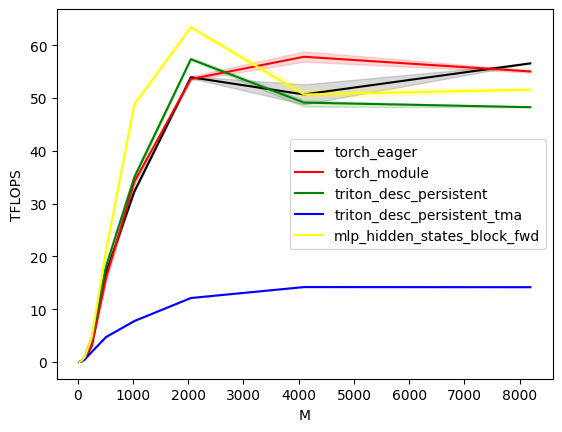

gated-mlp-performance:
        M       N       K  torch_eager  torch_module  triton_desc_persistent  triton_desc_persistent_tma  mlp_hidden_states_block_fwd
0    32.0    32.0    32.0     0.011636      0.011636                0.021333                    0.014222                     0.018286
1    64.0    64.0    64.0     0.085333      0.083379                0.146286                    0.085333                     0.146286
2   128.0   128.0   128.0     0.598502      0.587767                0.914988                    0.481882                     0.910222
3   256.0   256.0   256.0     3.120762      3.266592                4.681143                    1.927529                     4.681143
4   512.0   512.0   512.0    16.912516     15.887515               18.078896                    4.723315                    20.971521
5  1024.0  1024.0  1024.0    32.263877     34.100031               34.952534                    7.752873                    48.770977
6  2048.0  2048.0  2048.0    53.946030 

In [14]:
def is_cuda():
    return triton.runtime.driver.active.get_current_target().backend == "cuda"

ref_lib = 'cuBLAS' if is_cuda() else 'rocBLAS'
TORCH_HAS_FP8 = hasattr(torch, "float8_e5m2")

configs = []
for fp8_inputs in [True]:
    configs.append(
        triton.testing.Benchmark(
            x_names=["M", "N", "K"],  # Argument names to use as an x-axis for the plot
            x_vals=[int(2 ** i) for i in np.arange(5, 14, 1)],  # Different possible values for `x_name`
            line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
            # Possible values for `line_arg`
            # Don't compare to cublas for fp8 cases as torch.matmul doesn't support fp8 at the moment.
            line_vals=matmul_names, #["triton"] if fp8_inputs else [ref_lib.lower(), "triton"],  # Label name for the lines
            line_names=matmul_names, #["Triton"] if fp8_inputs else [ref_lib, "Triton"],  # Line styles
            styles=[(x, "-") for x, _ in zip(colors,matmul_names)], # ("green", "-"), ("blue", "-")],
            ylabel="TFLOPS",  # Label name for the y-axis
            plot_name="gated-mlp-performance",  # Name for the plot, used also as a file name for saving the plot.
            args={"fp8_inputs": fp8_inputs},
        ))

@triton.testing.perf_report(configs)
def benchmark(M, N, K, provider, fp8_inputs):
    
    DTYPE = torch.float16
    print(f"{provider=}, {DTYPE=}, {M=}, {N=}, {K=}")
    
    x = torch.randn((M, K), device=DEVICE, dtype=DTYPE)
    # b = torch.randn((K, N), device=DEVICE, dtype=torch.float16)
    
    gmlp = NaiveGatedMLP(
        hidden_act='silu', 
        hidden_size=N, 
        intermediate_size=N, 
        bias=False, 
        dropout_p=0.,
    ).to(DEVICE).to(DTYPE)
    
    if provider == "torch_module":
        fwd = gmlp
    else:
        fwd = partial(
            MAP_FUN[provider], 
            WT_up=gmlp.up_proj.weight, 
            b_up=gmlp.up_proj.bias, 
            WT_gp=gmlp.gate_proj.weight, 
            b_gp=gmlp.gate_proj.bias, 
            act_fn=gmlp.act_fn, 
            dropout_p=gmlp.dropout.p,
        )

    quantiles = [0.5, 0.2, 0.8]
    ms, min_ms, max_ms = triton.testing.do_bench(lambda: fwd(x), quantiles=quantiles) 
    perf = lambda ms: 4 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark.run(show_plots=True, print_data=True)

In [ ]:
# 0  8192.0  8192.0  8192.0  1490.273147   1486.469337              1178.68129                 1141.045679                  1111.569922


In [21]:
print(_fwd_kernel.best_config)
print(_fwd_kernel_tma.best_config)
print(_block_fwd_kernel.best_config)

BLOCK_SIZE_M: 32, BLOCK_SIZE_N: 32, BLOCK_SIZE_K: 32, GROUP_SIZE_M: 4, EPILOGUE_SUBTILE: False, num_warps: 4, num_ctas: 1, num_stages: 2, maxnreg: None
BLOCK_SIZE_M: 64, BLOCK_SIZE_N: 32, BLOCK_SIZE_K: 32, GROUP_SIZE_M: 4, EPILOGUE_SUBTILE: False, num_warps: 4, num_ctas: 1, num_stages: 2, maxnreg: None
BLOCK_SIZE_M: 64, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 16, GROUP_SIZE_M: 4, num_warps: 4, num_ctas: 1, num_stages: 3, maxnreg: None


In [ ]:
print(_fwd_kernel.best_config)
print(_fwd_kernel_tma.best_config)
print(_block_fwd_kernel.best_config)


BLOCK_SIZE_M: 32, BLOCK_SIZE_N: 32, BLOCK_SIZE_K: 64, GROUP_SIZE_M: 8, EPILOGUE_SUBTILE: False, num_warps: 4, num_ctas: 1, num_stages: 2, maxnreg: None
BLOCK_SIZE_M: 64, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 32, GROUP_SIZE_M: 2, EPILOGUE_SUBTILE: False, num_warps: 4, num_ctas: 1, num_stages: 2, maxnreg: None
BLOCK_SIZE_M: 32, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 32, GROUP_SIZE_M: 4, num_warps: 4, num_ctas: 1, num_stages: 3, maxnreg: None


In [ ]:
configs = []
for fp8_inputs in [True]:
    configs.append(
        triton.testing.Benchmark(
            x_names=["M", "N", "K"],  # Argument names to use as an x-axis for the plot
            # x_vals=[int(2 ** (i-0.5)) for i in np.arange(5, 13, 1)][::-1],  # Different possible values for `x_name`
            x_vals=[int(2 ** i) for i in np.arange(5, 13, 1)][::-1],  # Different possible values for `x_name`
            line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
            # Possible values for `line_arg`
            # Don't compare to cublas for fp8 cases as torch.matmul doesn't support fp8 at the moment.
            line_vals=matmul_names, #["triton"] if fp8_inputs else [ref_lib.lower(), "triton"],  # Label name for the lines
            line_names=matmul_names, #["Triton"] if fp8_inputs else [ref_lib, "Triton"],  # Line styles
            styles=[(x, "-") for x, _ in zip(colors,matmul_names)], # ("green", "-"), ("blue", "-")],
            ylabel="TFLOPS",  # Label name for the y-axis
            plot_name="gated-mlp-performance",  # Name for the plot, used also as a file name for saving the plot.
            args={"fp8_inputs": fp8_inputs},
        ))

@triton.testing.perf_report(configs)
def benchmark(M, N, K, provider, fp8_inputs):

    M *= 2
    M += 8
    
    # if M % 16 != 0:
    #     M = M + (16 - M % 16)    
    # if N % 16 != 0:
    #     N = N + (16 - N % 16)    
    # if K % 16 != 0:
    #     K = K + (16 - K % 16)
    
    DTYPE = torch.float16
    print(f"{provider=}, {DTYPE=}, {M=}, {N=}, {K=}")
    
    x = torch.randn((M, K), device=DEVICE, dtype=DTYPE)
    # b = torch.randn((K, N), device=DEVICE, dtype=torch.float16)
    
    gmlp = NaiveGatedMLP(
        hidden_act='silu', 
        hidden_size=N, 
        intermediate_size=N, 
        bias=False, 
        dropout_p=0.,
    ).to(DEVICE).to(DTYPE)
    
    if provider == "torch_module":
        fwd = gmlp
    else:
        fwd = partial(
            MAP_FUN[provider], 
            WT_up=gmlp.up_proj.weight, 
            b_up=gmlp.up_proj.bias, 
            WT_gp=gmlp.gate_proj.weight, 
            b_gp=gmlp.gate_proj.bias, 
            act_fn=gmlp.act_fn, 
            dropout_p=gmlp.dropout.p,
        )

    quantiles = [0.5, 0.2, 0.8]
    ms, min_ms, max_ms = triton.testing.do_bench(lambda: fwd(x), quantiles=quantiles) 
    perf = lambda ms: 4 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark.run(show_plots=True, print_data=True)

provider='torch_eager', DTYPE=torch.float16, M=8200, N=4096, K=4096
provider='torch_module', DTYPE=torch.float16, M=8200, N=4096, K=4096
provider='triton_desc_persistent', DTYPE=torch.float16, M=8200, N=4096, K=4096
Autotuning kernel _fwd_kernel with config BLOCK_SIZE_M: 32, BLOCK_SIZE_N: 32, BLOCK_SIZE_K: 32, GROUP_SIZE_M: 4, EPILOGUE_SUBTILE: False, num_warps: 4, num_ctas: 1, num_stages: 2, maxnreg: None
Autotuning kernel _fwd_kernel with config BLOCK_SIZE_M: 32, BLOCK_SIZE_N: 32, BLOCK_SIZE_K: 32, GROUP_SIZE_M: 8, EPILOGUE_SUBTILE: False, num_warps: 4, num_ctas: 1, num_stages: 2, maxnreg: None
Autotuning kernel _fwd_kernel with config BLOCK_SIZE_M: 32, BLOCK_SIZE_N: 32, BLOCK_SIZE_K: 64, GROUP_SIZE_M: 4, EPILOGUE_SUBTILE: False, num_warps: 4, num_ctas: 1, num_stages: 2, maxnreg: None
Autotuning kernel _fwd_kernel with config BLOCK_SIZE_M: 32, BLOCK_SIZE_N: 32, BLOCK_SIZE_K: 64, GROUP_SIZE_M: 8, EPILOGUE_SUBTILE: False, num_warps: 4, num_ctas: 1, num_stages: 2, maxnreg: None
Autotuni

Autotuning kernel _fwd_kernel_tma with config BLOCK_SIZE_M: 256, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 32, GROUP_SIZE_M: 4, EPILOGUE_SUBTILE: False, num_warps: 8, num_ctas: 1, num_stages: 2, maxnreg: None
Autotuning kernel _fwd_kernel_tma with config BLOCK_SIZE_M: 256, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 32, GROUP_SIZE_M: 8, EPILOGUE_SUBTILE: False, num_warps: 4, num_ctas: 1, num_stages: 2, maxnreg: None
Autotuning kernel _fwd_kernel_tma with config BLOCK_SIZE_M: 256, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 32, GROUP_SIZE_M: 8, EPILOGUE_SUBTILE: False, num_warps: 8, num_ctas: 1, num_stages: 2, maxnreg: None
Autotuning kernel _fwd_kernel_tma with config BLOCK_SIZE_M: 256, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 64, GROUP_SIZE_M: 2, EPILOGUE_SUBTILE: False, num_warps: 4, num_ctas: 1, num_stages: 2, maxnreg: None
Autotuning kernel _fwd_kernel_tma with config BLOCK_SIZE_M: 256, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 64, GROUP_SIZE_M: 2, EPILOGUE_SUBTILE: False, num_warps: 8, num_ctas: 1, num_stages: 2, maxnreg: None
Autot

KeyboardInterrupt: 